# Credit Card Fraud Detection — Classificação binária (fraude vs. legítima)

Notebook do domínio **Fraude em cartão de crédito** do Trabalho A2 de Data Science.

**Classe positiva do domínio:** `Class = 1` (a pergunta que o modelo responde é *"esta transação é fraude?"*).

Fonte dos dados: Machine Learning Group (ULB) — Credit Card Fraud Detection (licença ODbL).

> **Nota de metodologia:** este é o domínio mais desbalanceado (~0,17% de fraude) e com mais linhas
> (284.807). Por isso, o ajuste de hiperparâmetros (seção 5) é feito numa subamostra estratificada de
> 20.000 linhas — para viabilizar o tempo de execução — e o modelo final, com os hiperparâmetros
> escolhidos, é treinado na base de treino **completa**.

## 1. Carregamento dos dados e definição da classe positiva

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Verificação do balanceamento (item iii)

In [2]:
contagem = df["Class"].value_counts().sort_index()
percentual = (contagem / contagem.sum() * 100).round(4)
pd.DataFrame({"qtd": contagem, "%": percentual})

,qtd,%
Class,,
0,284315,99.8273
1,492,0.1727


Desbalanceamento extremo (~0,17% de fraude). Acurácia é completamente inútil aqui — um modelo que
sempre prevê "não fraude" já acertaria 99,8%. AUC-PR é a métrica que realmente importa neste domínio.

## 3. Separação treino / validação / teste (item iv)

60% treino / 20% validação / 20% teste, estratificado pela classe.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

colunas_features = [c for c in df.columns if c != "Class"]
X = df[colunas_features].values
y = df["Class"].values

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp_raw, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Treino={len(y_train)}  Validação={len(y_val)}  Teste={len(y_test)}")
print(f"Proporção de fraude -> treino={y_train.mean():.5f}  val={y_val.mean():.5f}  teste={y_test.mean():.5f}")

Treino=170884  Validação=56961  Teste=56962
Proporção de fraude -> treino=0.00173  val=0.00172  teste=0.00174


## 4. Pré-processamento (item v)

`Time` e `Amount` são padronizados (`StandardScaler`, ajustado só no treino); as demais colunas
(V1–V28) já são componentes de PCA, previamente padronizadas na origem dos dados.

In [4]:
idx_time_amount = [colunas_features.index("Time"), colunas_features.index("Amount")]
scaler = StandardScaler()

X_train = X_train_raw.copy().astype(float)
X_val = X_val_raw.copy().astype(float)
X_test = X_test_raw.copy().astype(float)
X_train[:, idx_time_amount] = scaler.fit_transform(X_train_raw[:, idx_time_amount])
X_val[:, idx_time_amount] = scaler.transform(X_val_raw[:, idx_time_amount])
X_test[:, idx_time_amount] = scaler.transform(X_test_raw[:, idx_time_amount])
feature_names = np.array(colunas_features)
X_train.shape

(170884, 30)

## 5. Comparação de pelo menos 3 algoritmos (item vi)

Mesma metodologia dos outros domínios (Regressão Logística, Random Forest, Hist Gradient Boosting),
com uma diferença: por causa do tamanho da base, o `GridSearchCV` roda numa **subamostra
estratificada de 20.000 linhas**; o modelo com os melhores hiperparâmetros de cada algoritmo é então
retreinado na base de treino **completa** antes de ser avaliado na validação.

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

grids = {
    "Regressão Logística": (LogisticRegression(max_iter=1000, random_state=42),
                             {"C": [0.1, 1, 10], "class_weight": [None, "balanced"]}),
    "Random Forest": (RandomForestClassifier(random_state=42, n_jobs=1),
                       {"n_estimators": [150], "max_depth": [None, 12], "class_weight": [None, "balanced"]}),
    "Hist Gradient Boosting": (HistGradientBoostingClassifier(random_state=42),
                                {"max_iter": [100], "max_depth": [None, 10], "learning_rate": [0.1]}),
}

rng = np.random.default_rng(42)
idx_pos = np.where(y_train == 1)[0]
idx_neg = np.where(y_train == 0)[0]
n_pos_sub = min(len(idx_pos), max(20, int(len(idx_pos) * 20000 / len(X_train))))
n_neg_sub = 20000 - n_pos_sub
sel = np.concatenate([rng.choice(idx_pos, n_pos_sub, replace=False), rng.choice(idx_neg, n_neg_sub, replace=False)])
X_sub, y_sub = X_train[sel], y_train[sel]

linhas = []
modelos_ajustados = {}
for nome, (estimador, grade) in grids.items():
    busca = GridSearchCV(estimador, grade, scoring="average_precision", cv=3, n_jobs=1, refit=False)
    busca.fit(X_sub, y_sub)
    final = estimador.__class__(**{**estimador.get_params(), **busca.best_params_})
    final.fit(X_train, y_train)
    prob_val = final.predict_proba(X_val)[:, 1]
    linhas.append({
        "Algoritmo": nome,
        "Melhores hiperparâmetros (subamostra n=20000)": busca.best_params_,
        "AUC-PR (validação)": round(average_precision_score(y_val, prob_val), 4),
        "AUC-ROC (validação)": round(roc_auc_score(y_val, prob_val), 4),
    })
    modelos_ajustados[nome] = final

resultados = pd.DataFrame(linhas).sort_values("AUC-PR (validação)", ascending=False).reset_index(drop=True)
melhor_nome = resultados.iloc[0]["Algoritmo"]
melhor_modelo = modelos_ajustados[melhor_nome]
resultados

,Algoritmo,Melhores hiperparâmetros (subamostra n=20000),AUC-PR (validação),AUC-ROC (validação)
0,Random Forest,"{'class_weight': 'balanced', 'max_depth': 12, ...",0.7742,0.9542
1,Regressão Logística,"{'C': 0.1, 'class_weight': None}",0.6701,0.9649
2,Hist Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 10, 'max_i...",0.4271,0.8543


*(preencher aqui a leitura dos resultados com as próprias palavras da equipe)*

## 6. Avaliação dos 3 algoritmos e do melhor modelo no conjunto de teste (item vii)

In [6]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, precision_recall_curve, auc)

def metricas_completas(modelos, X, y, limiar=0.5):
    linhas = []
    for nome, modelo in modelos.items():
        prob = modelo.predict_proba(X)[:, 1]
        pred = (prob >= limiar).astype(int)
        linhas.append({
            "Algoritmo": nome, "Threshold": limiar,
            "Acurácia": round(accuracy_score(y, pred), 4),
            "Precisão": round(precision_score(y, pred, zero_division=0), 4),
            "Recall": round(recall_score(y, pred, zero_division=0), 4),
            "F1": round(f1_score(y, pred, zero_division=0), 4),
            "AUC-ROC": round(roc_auc_score(y, prob), 4),
            "AUC-PR (Average Precision)": round(average_precision_score(y, prob), 4),
            "Matriz de confusão [[TN FP][FN TP]]": confusion_matrix(y, pred).tolist(),
        })
    return pd.DataFrame(linhas)

tabela_val_3algoritmos = metricas_completas(modelos_ajustados, X_val, y_val)
tabela_val_3algoritmos

,Algoritmo,Threshold,Acurácia,Precisão,Recall,F1,AUC-ROC,AUC-PR (Average Precision),Matriz de confusão [[TN FP][FN TP]]
0,Regressão Logística,0.5,0.9991,0.8267,0.6327,0.7168,0.9649,0.6701,"[[56850, 13], [36, 62]]"
1,Random Forest,0.5,0.9993,0.8452,0.7245,0.7802,0.9542,0.7742,"[[56850, 13], [27, 71]]"
2,Hist Gradient Boosting,0.5,0.9980,0.4516,0.7143,0.5534,0.8543,0.4271,"[[56778, 85], [28, 70]]"


In [7]:
import matplotlib.pyplot as plt

proba_test = melhor_modelo.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print(f"Melhor modelo: {melhor_nome}")
print(f"Acurácia: {accuracy_score(y_test, pred_test):.4f}")
print(f"Precisão: {precision_score(y_test, pred_test):.4f}")
print(f"Recall: {recall_score(y_test, pred_test):.4f}")
print(f"F1: {f1_score(y_test, pred_test):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, proba_test):.4f}")
print(f"AUC-PR (Average Precision): {average_precision_score(y_test, proba_test):.4f}")
print("Matriz de confusão [[TN FP][FN TP]]:")
print(confusion_matrix(y_test, pred_test))

Melhor modelo: Random Forest
Acurácia: 0.9995
Precisão: 0.8864
Recall: 0.7879
F1: 0.8342
AUC-ROC: 0.9694
AUC-PR (Average Precision): 0.8556
Matriz de confusão [[TN FP][FN TP]]:
[[56853    10]
 [   21    78]]


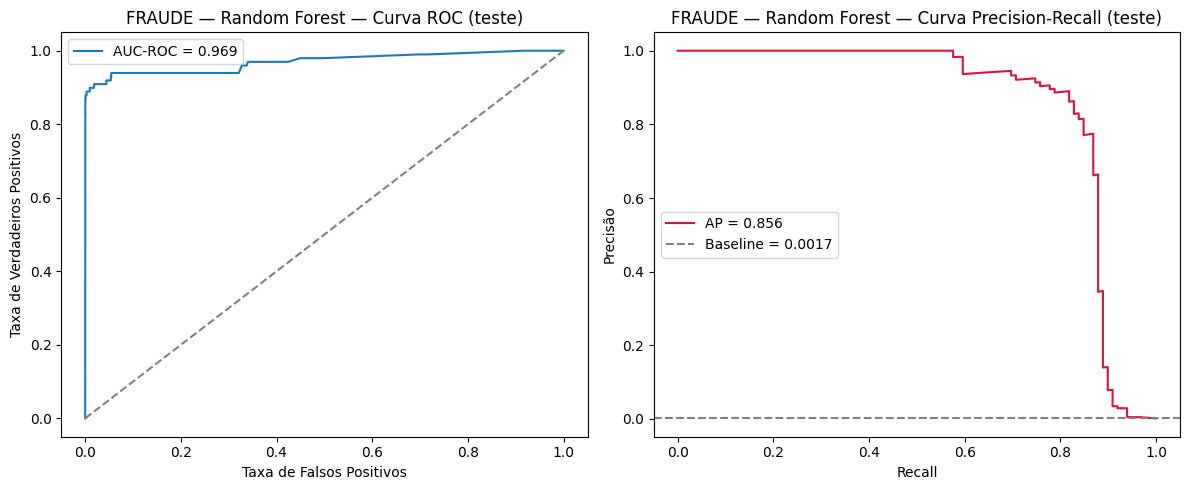

In [8]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f"AUC-ROC = {auc(fpr, tpr):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("Taxa de Falsos Positivos"); axes[0].set_ylabel("Taxa de Verdadeiros Positivos")
axes[0].set_title(f"FRAUDE — {melhor_nome} — Curva ROC (teste)"); axes[0].legend()

axes[1].plot(rec, prec, color="crimson", label=f"AP = {average_precision_score(y_test, proba_test):.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label=f"Baseline = {y_test.mean():.4f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisão")
axes[1].set_title(f"FRAUDE — {melhor_nome} — Curva Precision-Recall (teste)"); axes[1].legend()
fig.tight_layout()
plt.show()

A área sob a PR reportada é a **Average Precision (AP)**, distinta da integração trapezoidal simples
sobre a curva — diferença que importa mais aqui do que nos outros domínios, dado o desbalanceamento
extremo.

*(preencher aqui a leitura dos números com as próprias palavras da equipe)*

## 7. SHAP — explicação do melhor modelo (item viii)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


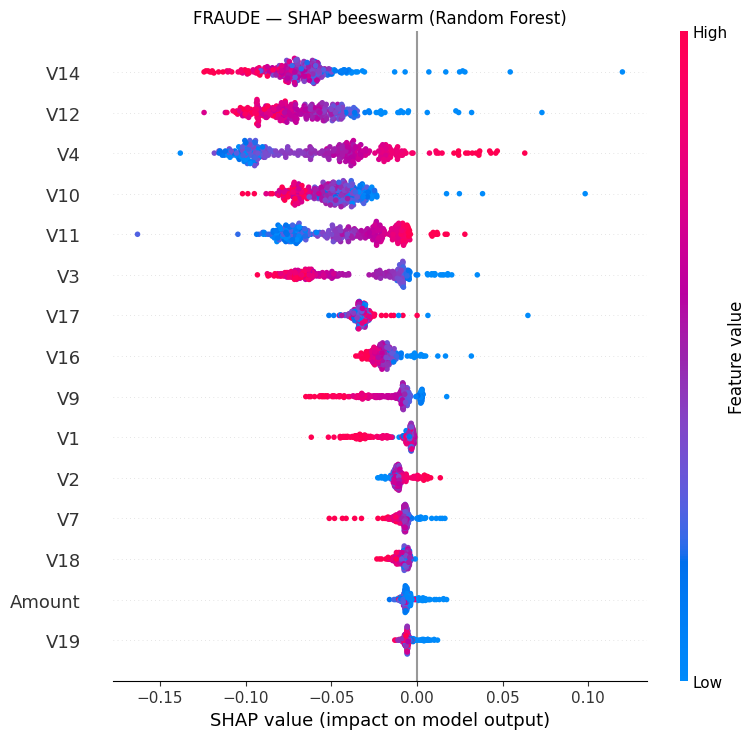

In [9]:
import shap

idx_amostra = np.random.default_rng(42).choice(len(X_test), size=min(300, len(X_test)), replace=False)
amostra = X_test[idx_amostra]

if melhor_nome == "Regressão Logística":
    fundo = shap.sample(amostra, min(200, amostra.shape[0]))
    explainer = shap.LinearExplainer(melhor_modelo, fundo)
    valores_shap = explainer.shap_values(amostra)
else:
    explainer = shap.TreeExplainer(melhor_modelo)
    valores_shap = explainer.shap_values(amostra)
    if isinstance(valores_shap, list):
        valores_shap = valores_shap[1]
    if valores_shap.ndim == 3:
        valores_shap = valores_shap[:, :, 1]

shap.summary_plot(valores_shap, amostra, feature_names=feature_names, max_display=15, show=False)
plt.title(f"FRAUDE — SHAP beeswarm ({melhor_nome})")
plt.tight_layout()
plt.show()

*(preencher aqui a leitura do gráfico SHAP com as próprias palavras da equipe)*

## 8. Programa da Parte 1 — histograma e faixas de decisão (reutilizável)

Mesma função dos outros dois notebooks — reutilizável para qualquer domínio.

In [10]:
def analisar_faixas_decisao(y_real, y_prob, largura_intervalo=10, t1=None, t2=None,
                             classe_positiva=1, titulo="Distribuição de Probabilidades",
                             escala_log_y=False):
    y_real = np.asarray(y_real)
    y_prob = np.asarray(y_prob, dtype=float)
    prob_pct = y_prob * 100 if y_prob.max() <= 1.0 else y_prob

    n_faixas = int(round(100 / largura_intervalo))
    bordas = np.linspace(0, 100, n_faixas + 1)
    todas_contagens, _ = np.histogram(prob_pct, bins=bordas)
    positivos_mask = (y_real == classe_positiva)
    positivos_contagens, _ = np.histogram(prob_pct[positivos_mask], bins=bordas)

    total = len(prob_pct)
    todas_pct = todas_contagens / total * 100
    positivos_pct = positivos_contagens / total * 100

    fig, ax = plt.subplots(figsize=(10, 6))
    centros = (bordas[:-1] + bordas[1:]) / 2
    largura = largura_intervalo * 0.9
    ax.bar(centros, todas_pct, width=largura, color="steelblue", alpha=0.6, label="Todas as instâncias", edgecolor="black")
    ax.bar(centros, positivos_pct, width=largura * 0.6, color="crimson", alpha=0.8,
           label=f"Instâncias com rótulo real = {classe_positiva}", edgecolor="black")

    if escala_log_y:
        ax.set_yscale("log")
        nao_zero = np.concatenate([todas_pct[todas_pct > 0], positivos_pct[positivos_pct > 0]])
        ax.set_ylim(bottom=(nao_zero.min() / 2 if len(nao_zero) else 1e-3),
                    top=max(todas_pct.max(), positivos_pct.max()) * 4)
    else:
        ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

    def posicao_y(frac):
        if escala_log_y:
            lo, hi = np.log10(ax.get_ylim()[0]), np.log10(ax.get_ylim()[1])
            return 10 ** (lo + frac * (hi - lo))
        return ax.get_ylim()[1] * frac

    if t1 is not None:
        t1_pct = t1 * 100 if t1 <= 1.0 else t1
        ax.axvline(t1_pct, color="black", linestyle="--")
        ax.text(t1_pct, posicao_y(0.93), f" t1={t1_pct:.1f}% ", rotation=90, va="top",
                ha="left" if t1_pct < 50 else "right", fontsize=9,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1))
    if t2 is not None:
        t2_pct = t2 * 100 if t2 <= 1.0 else t2
        ax.axvline(t2_pct, color="black", linestyle="--")
        ax.text(t2_pct, posicao_y(0.93), f" t2={t2_pct:.1f}% ", rotation=90, va="top",
                ha="left" if t2_pct < 50 else "right", fontsize=9,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1))

    ax.set_xlabel("Probabilidade estimada da classe positiva (%)")
    ax.set_ylabel("Percentual de instâncias (%)" + (" — escala log" if escala_log_y else ""))
    ax.set_title(titulo)
    ax.set_xlim(0, 100)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()

    tabela_faixas = None
    resumo_erros = None
    if t1 is not None and t2 is not None:
        t1_pct = t1 * 100 if t1 <= 1.0 else t1
        t2_pct = t2 * 100 if t2 <= 1.0 else t2
        faixa_neg = prob_pct < t1_pct
        faixa_manual = (prob_pct >= t1_pct) & (prob_pct < t2_pct)
        faixa_pos = prob_pct >= t2_pct

        linhas = []
        for nome, mascara in [("Negativa automática", faixa_neg), ("Análise manual", faixa_manual), ("Positiva automática", faixa_pos)]:
            n_faixa = int(mascara.sum())
            n_pos = int((mascara & positivos_mask).sum())
            n_neg = n_faixa - n_pos
            linhas.append({
                "Faixa": nome,
                f"% da população (n={total})": round(n_faixa / total * 100, 2),
                "Qtd positivos": n_pos,
                "% positivos na faixa": round(n_pos / n_faixa * 100, 2) if n_faixa else 0.0,
                "Qtd negativos": n_neg,
                "% negativos na faixa": round(n_neg / n_faixa * 100, 2) if n_faixa else 0.0,
            })
        tabela_faixas = pd.DataFrame(linhas)

        n_pos_total = int(positivos_mask.sum())
        n_neg_total = total - n_pos_total
        fn = int((positivos_mask & faixa_neg).sum())
        fp = int((~positivos_mask & faixa_pos).sum())
        resumo_erros = pd.DataFrame([{
            "Positivos → negativo automático (%)": round(fn / n_pos_total * 100, 2) if n_pos_total else 0.0,
            "Denominador (positivos reais)": n_pos_total,
            "Negativos → positivo automático (%)": round(fp / n_neg_total * 100, 2) if n_neg_total else 0.0,
            "Denominador (negativos reais)": n_neg_total,
        }])

    return fig, tabela_faixas, resumo_erros

## 9. Escolha dos pontos de corte na validação e aplicação ao teste (item ix)

Por causa do desbalanceamento extremo, o gráfico usa escala logarítmica no eixo Y — em escala
linear, praticamente todas as barras ficam esmagadas num único intervalo perto de 0%.

t1=0.00673  t2=0.08384


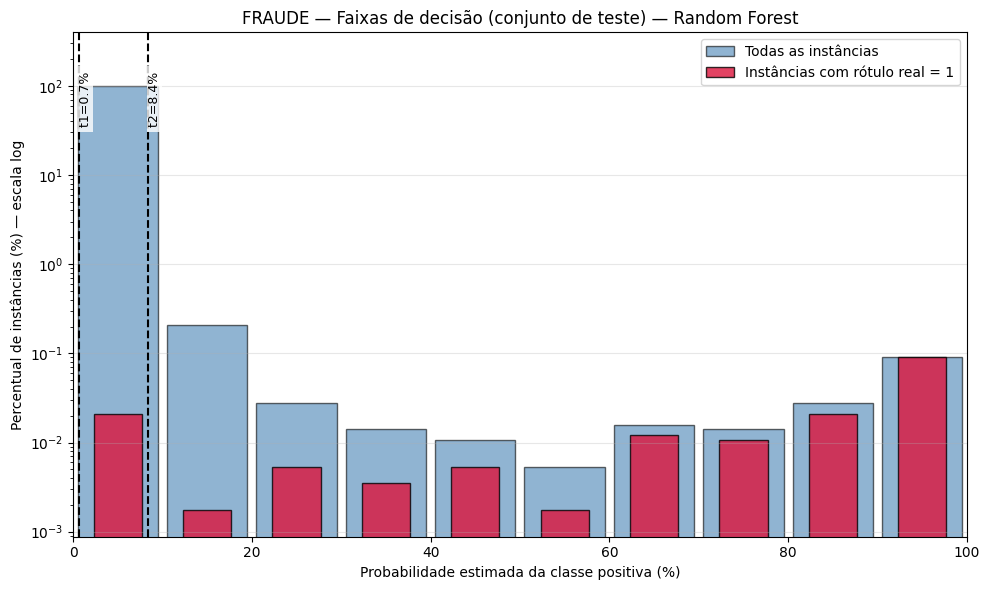

In [11]:
prob_val_melhor = melhor_modelo.predict_proba(X_val)[:, 1]
t1, t2 = np.quantile(prob_val_melhor, [0.90, 0.995])
print(f"t1={t1:.5f}  t2={t2:.5f}")

fig, tabela_faixas, resumo_erros = analisar_faixas_decisao(
    y_test, proba_test, largura_intervalo=10, t1=t1, t2=t2, escala_log_y=True,
    titulo=f"FRAUDE — Faixas de decisão (conjunto de teste) — {melhor_nome}")
plt.show()

In [12]:
print(tabela_faixas.to_string(index=False))

              Faixa  % da população (n=56962)  Qtd positivos  % positivos na faixa  Qtd negativos  % negativos na faixa
Negativa automática                      90.2              6                  0.01          51375                 99.99
     Análise manual                       9.3              5                  0.09           5294                 99.91
Positiva automática                       0.5             88                 31.21            194                 68.79


In [13]:
print(resumo_erros.to_string(index=False))

 Positivos → negativo automático (%)  Denominador (positivos reais)  Negativos → positivo automático (%)  Denominador (negativos reais)
                                6.06                             99                                 0.34                          56863


*(preencher aqui a política de triagem e a justificativa da equipe para t1/t2)*